# 1. Pre-process and save raw data to R tables

In [1]:
source("../util/packages.R")
source("../util/variables.R")
source("../util/add_treatment_to_df.R")
source("../util/samples_processing.R")
source("../util/outliers_processing.R")
source("../util/plot_helpers.R")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Learn more about sjPlot with 'browseVignettes("sjPlot")'.


Attaching package: ‘sjPlot’


The following object is masked from ‘package:ggplot2’:

    set_theme


Loading required package: lme4

Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack



Attaching package: ‘lmerTest’


The following object is masked from ‘package:lme4’:

    lmer


The following object is masked from ‘

In [2]:
AGGREGATION_PERIOD = "30 minutes"
AGGREGATION_PERIOD_IN_HOUR_FRACTION = 1/2

## 1.1. Raw outdoor PM and weather data

In [3]:
OUTDOOR_RAW <- read_delim(
    "../raw-data/fidas_outdoors.txt",
    delim = "\t",
    col_names = TRUE
) |>
    rename(
        pm25 = `PM2.5`,
        temperature = `T`,
        humidity = rH
    ) |>
    mutate(
        start_date = mdy_hms(paste(date, time), tz = "UTC"),  # Combine date and time
        co2 = 420
    ) |> select(start_date, pm25, temperature, humidity, co2)
    
head(OUTDOOR_RAW, n = 5)
write_rds(OUTDOOR_RAW, file.path("../R-table", "OUTDOOR_RAW.rds"))

New names:
• `0.000000` -> `0.000000...123`
• `0.000000` -> `0.000000...124`
• `` -> `...131`
Rows: 184255 Columns: 131
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr    (1): date
dbl  (127): PM1, PM2.5, PM4, PM10, PMtot, Cn, rH, T, p, status flow, status ...
lgl    (2): comment, ...131
time   (1): time

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


start_date,pm25,temperature,humidity,co2
<dttm>,<dbl>,<dbl>,<dbl>,<dbl>
2025-02-16 00:00:00,15.63391,21.20074,80.81273,420
2025-02-16 00:01:00,15.51769,21.19172,80.90945,420
2025-02-16 00:02:00,15.45553,21.19172,80.90945,420
2025-02-16 00:03:00,15.44281,21.17933,81.00084,420
2025-02-16 00:04:00,15.42881,21.17933,81.00084,420


## 1.2. Purifier data

In [4]:
PURIFIER_METADATA <- read_csv(file.path("../raw-data/purifiers_metadata.csv")) |>
  mutate(
    id = tolower(id),
    purifier_group = if_else(str_starts(name, "X"), "X", "Y")
  ) |>
  arrange(name)  # Sort by name
  
head(PURIFIER_METADATA, n = 5)

Rows: 14 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): id, name, alias

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


id,name,alias,purifier_group
<chr>,<chr>,<chr>,<chr>
040p-g00a-mlf0-8,X1,IQAir Atem X G00A-M,X
040p-e004-2lf0-8,X2,IQAir Atem X E004-2,X
040p-g00a-vlf0-8,X3,IQAir Atem X G00A-V,X
040p-k070-llf1-0,X4,IQAir Atem X K070-L,X
040p-g00a-wlf0-8,X5,IQAir Atem X G00A-W,X


In [5]:
ALL_PURIFIERS_DATA <- map_dfr(
  list.files(file.path("../raw-data/iqair-purifiers"), pattern = "\\.csv$", full.names = TRUE),
  function(file_path) {
    read_csv(file_path, col_types = cols()) |>
      rename_with(~ str_trim(.)) |>
      mutate(
        start_date = as.POSIXct(start_date, format = "%m/%d/%Y %H:%M", tz = "GMT") + hours(4),
        end_date = as.POSIXct(end_date, format = "%m/%d/%Y %H:%M", tz = "GMT") + hours(4),
        date = as.Date(end_date, tz = "GMT")
      ) |>
      relocate(c("start_date", "end_date", "date"), .after = purifier_id)
  }
) %>%
  filter(complete.cases(.)) # remove any row that contains NA value (must be used with %>% and not |>)

head(ALL_PURIFIERS_DATA, n = 5)
write_rds(ALL_PURIFIERS_DATA, file.path("../R-table", "ALL_PURIFIERS_DATA.rds"))

purifier_id,start_date,end_date,date,pm25,co2,temperature,humidity,is_fan_on
<chr>,<dttm>,<dttm>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
040p-e004-2lf0-8,2025-02-16 03:03:00,2025-02-16 03:03:00,2025-02-16,10,419,22.0,56.5,FALSE
040p-e004-2lf0-8,2025-02-16 03:04:00,2025-02-16 03:04:00,2025-02-16,10,419,21.9,56.5,FALSE
040p-e004-2lf0-8,2025-02-16 03:11:00,2025-02-16 03:11:00,2025-02-16,10,422,21.9,56.5,FALSE
040p-e004-2lf0-8,2025-02-16 03:16:00,2025-02-16 03:16:00,2025-02-16,10,421,21.9,56.5,FALSE
040p-e004-2lf0-8,2025-02-16 03:21:00,2025-02-16 03:21:00,2025-02-16,10,419,21.9,56.5,FALSE


## 1.3. Participant metadata

In [6]:
ALL_PARTICIPANTS_METADATA <- read_csv("../raw-data/participants.csv", col_types = cols()) |>
  mutate(
    purifier_id = tolower(purifier_id),
    room_type = factor(room_type, levels = c("Single", "Double"))
  ) |>
  left_join(
    PURIFIER_METADATA |>
      select(id, purifier_group) |>
      rename(
        purifier_id = id
      ),
    by = "purifier_id"
  )

head(ALL_PARTICIPANTS_METADATA, n = 5)

pseudonym,period_id,purifier_id,bmi,age_group,room_type,biological_sex,travel,purifier_group
<chr>,<dbl>,<chr>,<dbl>,<chr>,<fct>,<chr>,<chr>,<chr>
apple3,1,040p-g00a-mlf0-8,18.300,31-35,Single,Female,NA,X
banana8,1,040p-g00a-wlf0-8,18.600,18-20,Single,Female,"2025-03-12,2025-03-17",X
burger4,1,040p-g00a-klf0-8,21.007,18-20,Double,Female,NA,X
carrot7,1,040p-e004-2lf0-8,20.000,21-25,Single,Female,"2025-03-16,2025-03-24",X
elephant1,1,040p-k070-llf1-0,19.000,21-25,Single,Female,NA,X


In [7]:
write_rds(ALL_PARTICIPANTS_METADATA, file.path("../R-table", "ALL_PARTICIPANTS_METADATA.rds"))

## 1.4. Match purifier data to participant metadata

In [8]:
PURIFIER_AND_PARTICIPANT_DATA <- add_treatment_to_df(
  data = ALL_PURIFIERS_DATA  |>
          left_join(
            ALL_PARTICIPANTS_METADATA,
            by = "purifier_id"
          ),
  only_during_intervention = FALSE
) |> filter(treatment != "washout")

head(PURIFIER_AND_PARTICIPANT_DATA, n = 5)

Warning message in left_join(ALL_PURIFIERS_DATA, ALL_PARTICIPANTS_METADATA, by = "purifier_id"):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 4 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”


purifier_id,start_date,end_date,date,pm25,co2,temperature,humidity,is_fan_on,pseudonym,⋯,bmi,age_group,room_type,biological_sex,travel,purifier_group,treatment,first_or_second_half,treatment_boundary,treatment_order
<chr>,<dttm>,<dttm>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>,⋯,<dbl>,<chr>,<fct>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
040p-e004-2lf0-8,2025-02-16 03:03:00,2025-02-16 03:03:00,2025-02-16,10,419,22.0,56.5,FALSE,carrot7,⋯,20,21-25,Single,Female,"2025-03-16,2025-03-24",X,treatment1,first_half,before_start_first_half,12
040p-e004-2lf0-8,2025-02-16 03:04:00,2025-02-16 03:04:00,2025-02-16,10,419,21.9,56.5,FALSE,carrot7,⋯,20,21-25,Single,Female,"2025-03-16,2025-03-24",X,treatment1,first_half,before_start_first_half,12
040p-e004-2lf0-8,2025-02-16 03:11:00,2025-02-16 03:11:00,2025-02-16,10,422,21.9,56.5,FALSE,carrot7,⋯,20,21-25,Single,Female,"2025-03-16,2025-03-24",X,treatment1,first_half,before_start_first_half,12
040p-e004-2lf0-8,2025-02-16 03:16:00,2025-02-16 03:16:00,2025-02-16,10,421,21.9,56.5,FALSE,carrot7,⋯,20,21-25,Single,Female,"2025-03-16,2025-03-24",X,treatment1,first_half,before_start_first_half,12
040p-e004-2lf0-8,2025-02-16 03:21:00,2025-02-16 03:21:00,2025-02-16,10,419,21.9,56.5,FALSE,carrot7,⋯,20,21-25,Single,Female,"2025-03-16,2025-03-24",X,treatment1,first_half,before_start_first_half,12


## 1.5. Purifier temperature correction for treatment2

In [9]:
TEMPERATURE_CORRECTION <- tibble(
  treatment = c(TREATMENT_1_NAME, TREATMENT_2_NAME),
  mean_temp_diff = c(-0.8, 0.0)
)

In [10]:
# Helper functions to convert between relative and absolute humidity
# Temp in °C, RH in %, returns AH in g/m^3
rh_to_ah <- function(temp, rh) {
  es <- 6.112 * exp((17.67 * temp) / (temp + 243.5))  # saturation vapor pressure in hPa
  e <- rh / 100 * es  # actual vapor pressure
  ah <- 216.7 * (e / (temp + 273.15))  # absolute humidity
  return(ah)
}

# AH in g/m^3, temp in °C, returns RH in %
ah_to_rh <- function(temp, ah) {
  es <- 6.112 * exp((17.67 * temp) / (temp + 243.5))
  e <- ah * (temp + 273.15) / 216.7
  rh <- (e / es) * 100
  return(rh)
}

In [11]:
plot_dist_single_var <- function(data, var, var_label, group_var, major_breaks, bins = 30) {
  # Compute histogram per group
  hist_data <- data |>
    group_by(group = .data[[group_var]]) |>
    summarise(
      hist = list(hist(.data[[var]], breaks = bins, plot = FALSE)),
      .groups = "drop"
    ) |>
    mutate(
      counts = map(hist, ~ .x$counts),
      mids   = map(hist, ~ .x$mids)
    ) |>
    select(-hist) |>
    unnest(c(mids, counts)) |>
    group_by(group) |>
    mutate(
      density = counts / sum(counts)
    )

  # Mean values for vertical line
  mean_vals <- data |>
    group_by(.data[[group_var]]) |>
    summarise(mean_val = mean(.data[[var]], na.rm = TRUE), .groups = "drop")

  # Plot with geom_step
  p <- ggplot(hist_data, aes(x = mids, y = density, color = group)) +
    geom_step(linewidth = 2) +
    geom_vline(data = mean_vals,
               aes(xintercept = mean_val, color = .data[[group_var]]),
               linetype = "longdash", linewidth = 2, alpha = 0.5, show.legend = FALSE) +
    scale_color_manual(values = TREATMENT_FILL_VALUES, labels = TREATMENT_LABELS) +
    scale_x_continuous(breaks = major_breaks) +
    scale_y_continuous(
      labels = scales::label_number(accuracy = 0.01),
      limits = c(0, 0.15),
      breaks = seq(0, 0.15, by = 0.05)
    ) +
    labs(
      x = var_label,
      y = NULL,
      color = NULL
    ) +
    THEME_MINIMAL

  return(p)
}


In [12]:
# Step 1: Compute AH using original temperature and RH
NEW_PURIFIER_AND_PARTICIPANT_DATA <- PURIFIER_AND_PARTICIPANT_DATA |>
  mutate(
    ah = rh_to_ah(temperature, humidity)
  )

# Step 2: Shift temperature
NEW_PURIFIER_AND_PARTICIPANT_DATA <- NEW_PURIFIER_AND_PARTICIPANT_DATA |> left_join(TEMPERATURE_CORRECTION, by= "treatment") |>
  mutate(
    temperature_raw = temperature,
    temperature = temperature_raw - mean_temp_diff
  )

# Step 3: Compute new RH using original AH and shifted temperature
NEW_PURIFIER_AND_PARTICIPANT_DATA <- NEW_PURIFIER_AND_PARTICIPANT_DATA |>
  mutate(
    humidity_raw = humidity,
    humidity = ah_to_rh(temperature, ah)
  ) |>
  select(-ah, -mean_temp_diff)  # Drop temporary AH column if no longer needed

NEW_PURIFIER_AND_PARTICIPANT_DATA |>
    group_by(treatment) |>
    summarise(
        mean_temperature = round(mean(temperature, na.rm = TRUE), 1),
        sd_temperature = round(sd(temperature, na.rm = TRUE), 1),
        median_temperature = median(temperature, na.rm = TRUE),
        q1_temperature = quantile(temperature, 0.25, na.rm = TRUE),
        q3_temperature = quantile(temperature, 0.75, na.rm = TRUE),
        min_temperature = min(temperature, na.rm = TRUE),
        max_temperature = max(temperature, na.rm = TRUE),
        n = n()
    )

treatment,mean_temperature,sd_temperature,median_temperature,q1_temperature,q3_temperature,min_temperature,max_temperature,n
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
treatment1,21.7,1.8,21.9,20.6,23,15.8,26.3,345292
treatment2,21.9,1.8,22.1,21.0,23,15.9,27.4,293929


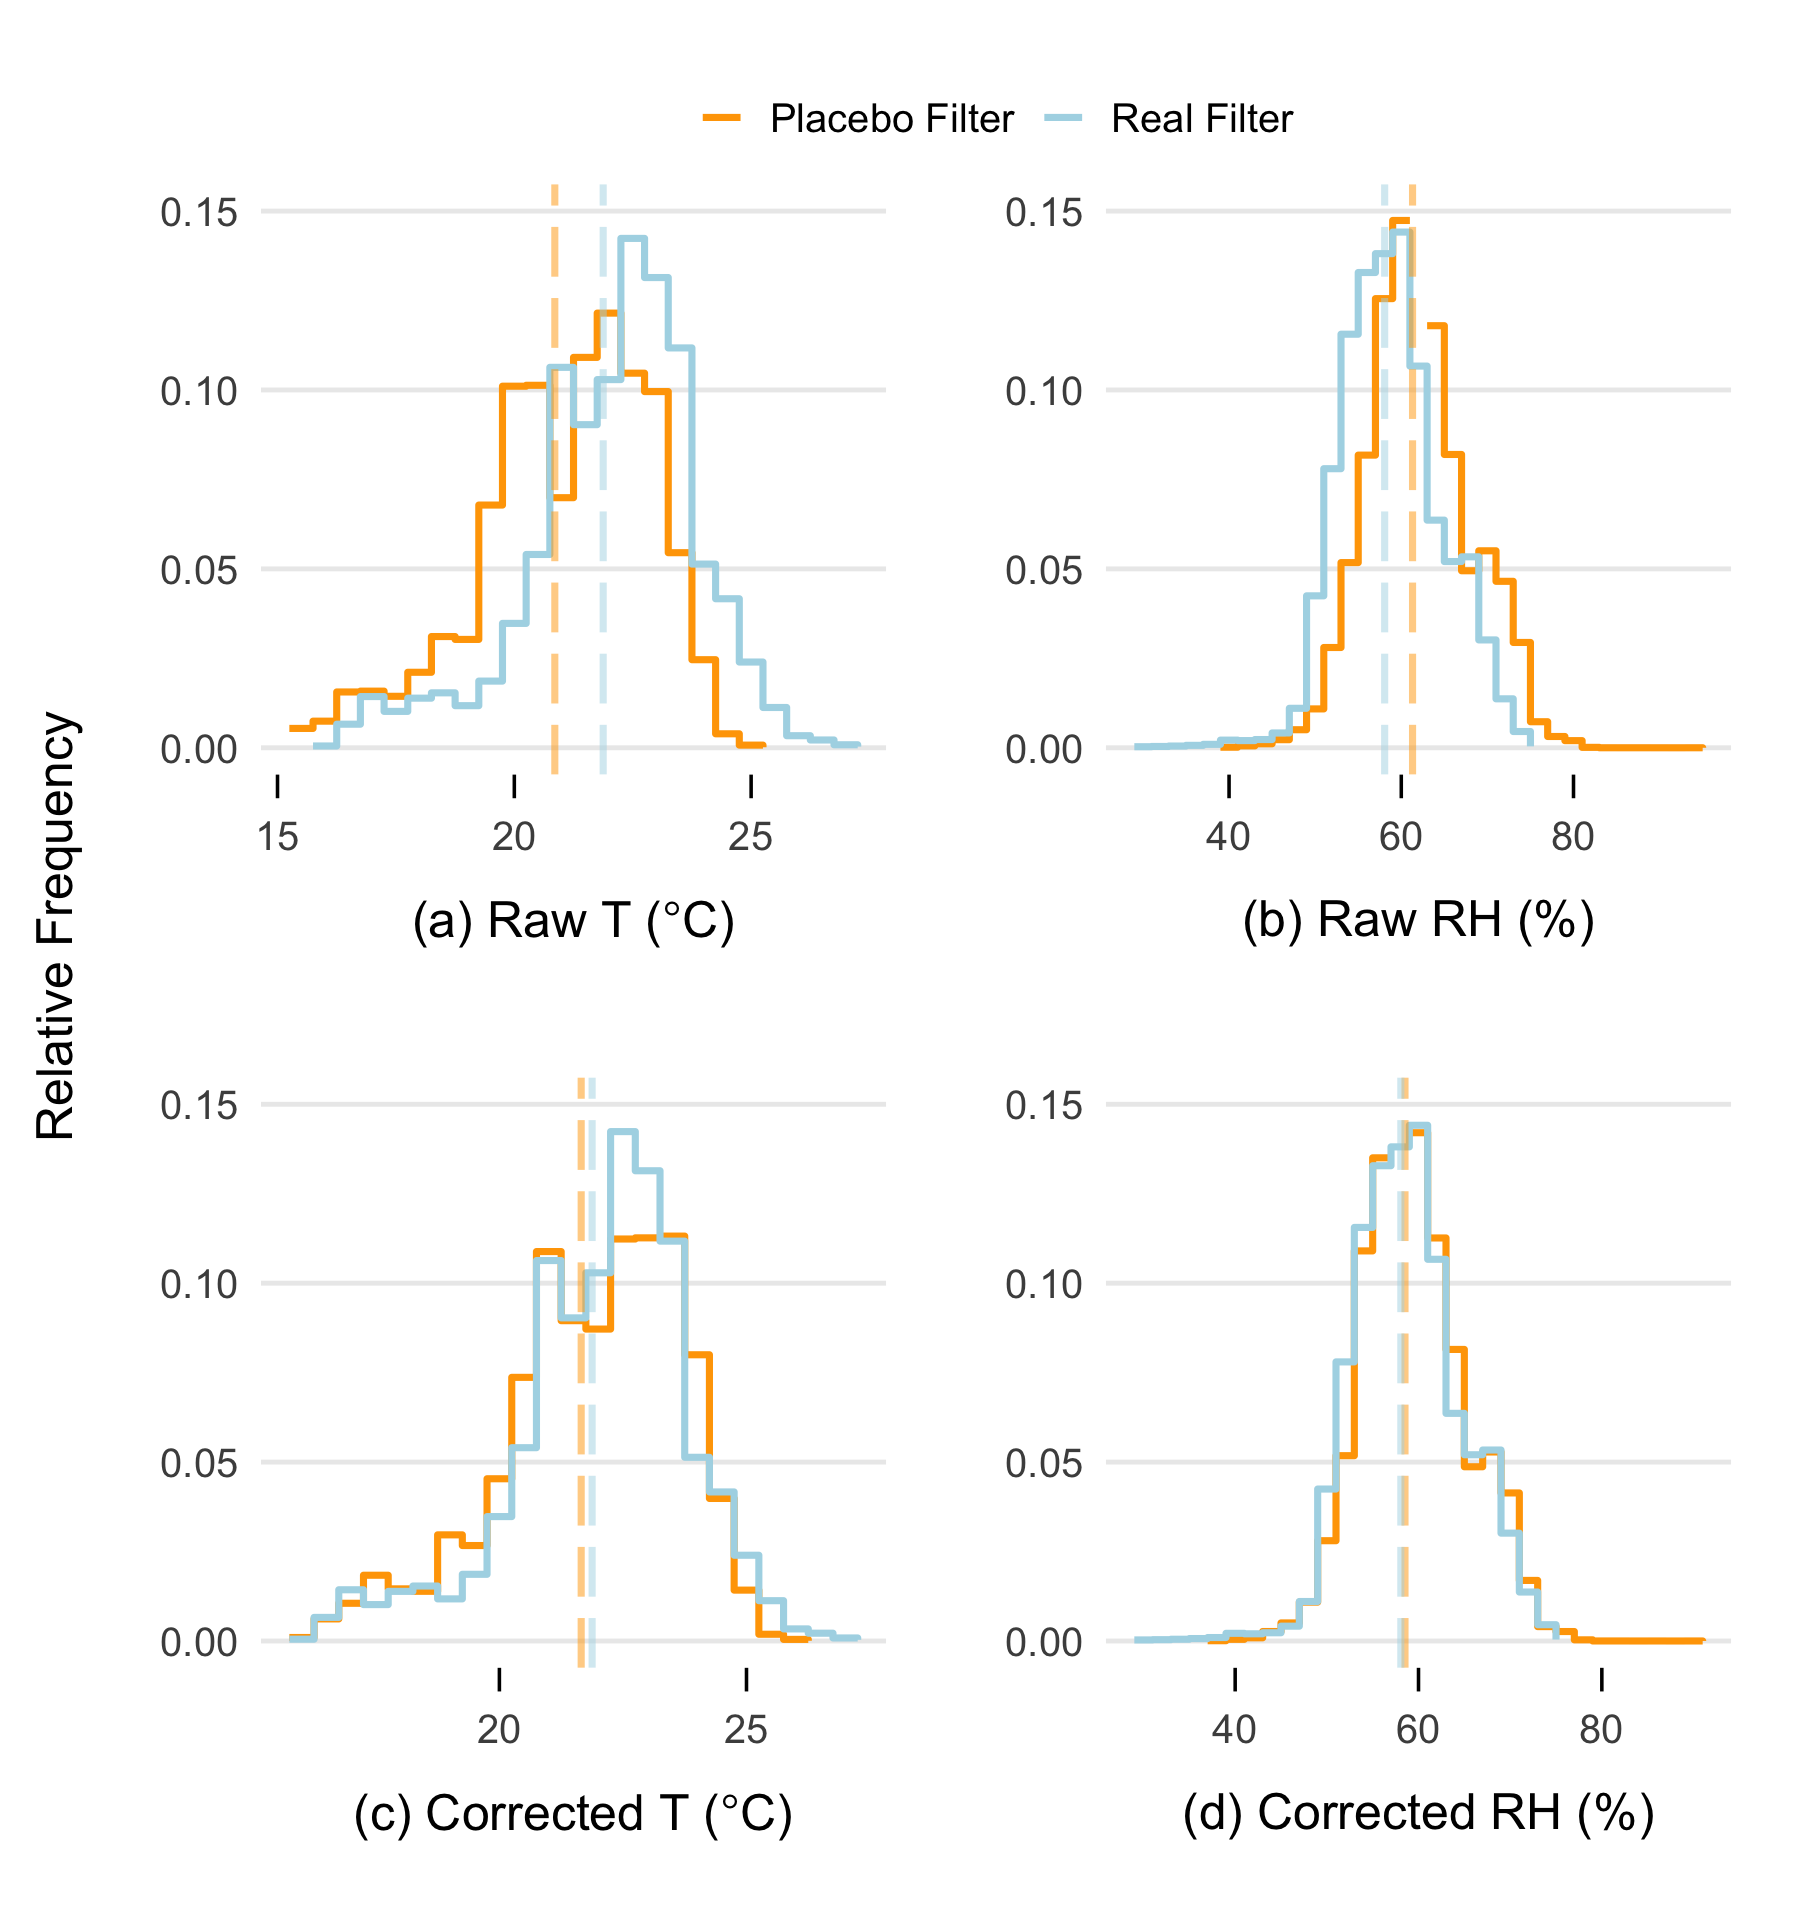

In [13]:
dimension <- plot_dimension(is_vertical = FALSE)
options(repr.plot.width = dimension$width, repr.plot.height = dimension$height)

temp_x_breaks <- seq(15, 30, by = 5)
humid_x_breaks <- seq(40, 80, by = 20)

p1 <- plot_dist_single_var(
  data = NEW_PURIFIER_AND_PARTICIPANT_DATA,
  var = "temperature_raw",
  var_label = expression("(a) Raw T ("*degree*C*")"),
  group_var = "treatment",
  major_breaks = temp_x_breaks
)

p2 <- plot_dist_single_var(
  data = NEW_PURIFIER_AND_PARTICIPANT_DATA,
  var = "humidity_raw",
  var_label = "(b) Raw RH (%)",
  group_var = "treatment",
  major_breaks = humid_x_breaks
)

p3 <- plot_dist_single_var(
  data = NEW_PURIFIER_AND_PARTICIPANT_DATA,
  var = "temperature",
  var_label = expression("(c) Corrected T ("*degree*C*")"),
  group_var = "treatment",
  major_breaks = temp_x_breaks
)

p4 <- plot_dist_single_var(
  data = NEW_PURIFIER_AND_PARTICIPANT_DATA,
  var = "humidity",
  var_label = "(d) Corrected RH (%)",
  group_var = "treatment",
  major_breaks = humid_x_breaks
)

options(repr.plot.width = dimension$width, repr.plot.height = dimension$height * 2)

plot_margin <- margin(36, 36, 36, 36)  # top, right, bottom, left (pt)

combined_plot <- (
  wrap_elements(
    textGrob(
      "Relative Frequency",
      rot = 90,
      gp = gpar(fontsize = 30)
    )
  ) +
  (
    p1 + theme(plot.margin = plot_margin) +
    p2 + theme(plot.margin = plot_margin) +
    p3 + theme(plot.margin = plot_margin) +
    p4 + theme(plot.margin = plot_margin) +
    plot_layout(ncol = 2, guides = "collect")
  )
) +
  plot_layout(widths = c(0.05, 1)) &
  theme(legend.position = "top")

combined_plot

ggsave("../visualization/temperature_humidity_histograms.pdf", combined_plot, width = dimension$width, height = dimension$height * 2, dpi = 300)

In [14]:
# Remove before_start (before the start of the intervention) data before saving
NEW_PURIFIER_AND_PARTICIPANT_DATA <- NEW_PURIFIER_AND_PARTICIPANT_DATA |>
      filter(!treatment_boundary %in% c("before_start_first_half", "before_start_second_half"))

In [15]:
write_rds(NEW_PURIFIER_AND_PARTICIPANT_DATA, file.path("../R-table", "PURIFIER_AND_PARTICIPANT_DATA.rds"))

## 1.6. Raw health metric samples

In [16]:
ALL_SAMPLES_RAW_DATA <- process_data_file(
    file_path = "../raw-data/samples.csv",
    ALL_PARTICIPANTS_METADATA = ALL_PARTICIPANTS_METADATA
) |>
  mutate(
    value = case_when(
      sample_type_id == SPO2 ~ value * 100, # convert to % point
      TRUE ~ value
    ),
    barometric_pressure = case_when(
      sample_type_id == SPO2 ~ barometric_pressure * 1000, # hPa -> Pa
      TRUE ~ barometric_pressure
    )
  )

# HR: round down to 1-min first
# Numbering heart_rate_motion_context
hr_1min <- ALL_SAMPLES_RAW_DATA |>
  filter(sample_type_id == HR) |>
  mutate(
    start_date = floor_date(start_date, "1 minute"),
    end_date = floor_date(end_date, "1 minute"),
    heart_rate_motion_context = case_when(
      heart_rate_motion_context == 1 ~ -1, # sedentary
      heart_rate_motion_context == 2 ~ 1, # active
      TRUE ~ heart_rate_motion_context  # keep other values (like 0) as-is (uncategorized)
    )
  ) |>
  group_by(pseudonym, start_date, end_date, date) |>
  summarise(
    across(where(is.numeric), ~ mean(.x, na.rm = TRUE)),
    across(where(is.character), first),
    .groups = "drop"
  )

non_hr <- ALL_SAMPLES_RAW_DATA |>
  filter(sample_type_id != HR)

ALL_SAMPLES_RAW_DATA <- bind_rows(hr_1min, non_hr) |>
  arrange(pseudonym, start_date)

head(ALL_SAMPLES_RAW_DATA, n = 5)
write_rds(ALL_SAMPLES_RAW_DATA, file.path("../R-table", "ALL_SAMPLES_RAW_DATA.rds"))

pseudonym,start_date,end_date,date,value,count,heart_rate_motion_context,algorithm_version,barometric_pressure,period_id,treatment_order,uuid,sample_type_id,time_zone,purifier_group,treatment,first_or_second_half,treatment_boundary,has_undetermined_duration
<chr>,<dttm>,<dttm>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>
apple3,2025-02-17 00:00:00,2025-02-17 00:00:00,2025-02-17,51,1,0,NaN,NaN,1,12,40A02CFC-A9BC-4321-9126-CF3DA43C40BE,heart-rate,NA,X,treatment1,first_half,start_first_half,NA
apple3,2025-02-17 00:00:19,2025-02-17 23:50:22,2025-02-17,52,1,NA,NA,NA,1,12,765EDB23-187F-45B3-9B1B-DCF2A2381B77,resting-heart-rate,NA,X,treatment1,first_half,start_first_half,FALSE
apple3,2025-02-17 00:00:19,2025-02-17 00:00:19,2025-02-17,98,1,NA,NA,100742.7,1,12,8D351B75-992D-4003-9DCD-D782EA5A00B2,oxygen-saturation,NA,X,treatment1,first_half,start_first_half,FALSE
apple3,2025-02-17 00:03:00,2025-02-17 00:03:00,2025-02-17,49,1,0,NaN,NaN,1,12,0B8B14CF-9EE6-44E6-8A79-03E3FC7D8209,heart-rate,NA,X,treatment1,first_half,start_first_half,NA
apple3,2025-02-17 00:08:00,2025-02-17 00:08:00,2025-02-17,52,1,0,NaN,NaN,1,12,15BA7C39-2625-4947-83F6-31DE6EA83A25,heart-rate,NA,X,treatment1,first_half,start_first_half,NA


## 1.7. Travel dates

In [17]:
PARTICIPANTS_SELF_REPORTED_TRAVEL_DATES <- ALL_PARTICIPANTS_METADATA |>
    mutate(travel_dates = strsplit(as.character(travel), ";")) |>
    unnest(travel_dates) |>
    mutate(
        travel_range_start = as.Date(sub(",", "", str_extract(travel_dates, "^\\d{4}-\\d{2}-\\d{2}"))),
        travel_range_end = as.Date(str_extract(travel_dates, "\\d{4}-\\d{2}-\\d{2}$"))
    ) |>
    filter(!is.na(travel_range_start)) |>
    mutate(date = map2(travel_range_start, travel_range_end, seq, by = "day")) |>
    unnest(date) |>
    select(pseudonym, period_id, purifier_id, date) |>
    mutate(travel_info_method = "self-reported")

PARTICIPANTS_TRAVEL_DATES_FROM_TZ <- ALL_SAMPLES_RAW_DATA |>
    filter(sample_type_id == SLEEP, time_zone != "Asia/Dubai") |>
    distinct(pseudonym, period_id, date) |>
    left_join(ALL_PARTICIPANTS_METADATA, by = c("pseudonym", "period_id")) |>
    select(pseudonym, period_id, purifier_id, date) |>
    mutate(travel_info_method = "timezone")

PARTICIPANTS_TRAVEL_DATES <- bind_rows(PARTICIPANTS_SELF_REPORTED_TRAVEL_DATES, PARTICIPANTS_TRAVEL_DATES_FROM_TZ) |>
    select(pseudonym, period_id, purifier_id, date) |>
    distinct() |>  # Remove duplicated rows
    arrange(pseudonym, date)

head(PARTICIPANTS_TRAVEL_DATES, n = 5)
write_rds(PARTICIPANTS_TRAVEL_DATES, file.path("../R-table", "PARTICIPANTS_TRAVEL_DATES.rds"))

pseudonym,period_id,purifier_id,date
<chr>,<dbl>,<chr>,<date>
banana8,1,040p-g00a-wlf0-8,2025-03-12
banana8,1,040p-g00a-wlf0-8,2025-03-13
banana8,1,040p-g00a-wlf0-8,2025-03-14
banana8,1,040p-g00a-wlf0-8,2025-03-15
banana8,1,040p-g00a-wlf0-8,2025-03-16


## 1.8. Aggregate environment data aggregation to AGGREGATION_PERIOD

### 1.8.1. Purifier (at-home) data

In [18]:
at_home_data_aggregated <- NEW_PURIFIER_AND_PARTICIPANT_DATA |> 
    select(pseudonym, start_date, treatment, any_of(SENSOR_METRICS)) |>
    mutate(
        start_date = floor_date(start_date, AGGREGATION_PERIOD)
    ) |>
    group_by(pseudonym, start_date, treatment) |>
    summarise(across(where(is.numeric), ~ mean(.x, na.rm = TRUE)), .groups = "drop")

head(at_home_data_aggregated, n = 5)

pseudonym,start_date,treatment,pm25,co2,temperature,humidity
<chr>,<dttm>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
apple3,2025-02-17 00:00:00,treatment1,4.000000,625.8125,23.13750,55.34064
apple3,2025-02-17 00:30:00,treatment1,3.500000,614.9286,23.05000,55.94441
apple3,2025-02-17 01:00:00,treatment1,3.315789,631.4211,23.22105,55.52767
apple3,2025-02-17 01:30:00,treatment1,3.666667,646.8333,23.31667,56.04069
apple3,2025-02-17 02:00:00,treatment1,4.272727,649.3636,23.20909,56.83455


### 1.8.2. Outdoor data

In [19]:
outdoor_data_aggregated <- OUTDOOR_RAW |>
  select(start_date, any_of(SENSOR_METRICS)) |>
  mutate(
    start_date = floor_date(start_date, AGGREGATION_PERIOD),
  ) |>
  group_by(start_date) |>
  summarise(across(where(is.numeric), ~ mean(.x, na.rm = TRUE)), .groups = "drop")

head(outdoor_data_aggregated, n = 5)

start_date,pm25,co2,temperature,humidity
<dttm>,<dbl>,<dbl>,<dbl>,<dbl>
2025-02-16 00:00:00,15.26785,420,21.08267,81.37248
2025-02-16 00:30:00,15.77611,420,20.90655,82.22089
2025-02-16 01:00:00,13.87126,420,20.91350,82.69387
2025-02-16 01:30:00,14.78370,420,21.03939,82.79724
2025-02-16 02:00:00,16.94866,420,21.18872,83.10970


### 1.8.3. Indoors elsewhere data

In [20]:
# Estimate by using placebo filter data for all other purifiers
indoor_elsewhere_data_aggregated <- NEW_PURIFIER_AND_PARTICIPANT_DATA |> 
    filter(treatment == TREATMENT_1_NAME) |>
    select(start_date, all_of(SENSOR_METRICS)) |>
    mutate(
        start_date = floor_date(start_date, AGGREGATION_PERIOD)
    ) |>
    group_by(start_date) |>
    summarise(across(where(is.numeric), ~ mean(.x, na.rm = TRUE)), .groups = "drop") 

head(indoor_elsewhere_data_aggregated, n = 5)

start_date,pm25,co2,temperature,humidity
<dttm>,<dbl>,<dbl>,<dbl>,<dbl>
2025-02-17 00:00:00,5.108434,642.7831,22.03494,59.60010
2025-02-17 00:30:00,4.656716,638.3284,21.90149,61.56710
2025-02-17 01:00:00,4.054348,630.9239,22.10326,60.72974
2025-02-17 01:30:00,3.724638,625.0580,21.94058,60.66918
2025-02-17 02:00:00,3.866667,629.4000,22.08500,60.80601


### 1.8.4. Join to one single table for all location

In [21]:
ALL_LOCATION_DATA <- bind_rows(
  remove_outliers_iqr_method(
      data = at_home_data_aggregated |> mutate(location_type = "home"),
      value_column = "pm25",
      group_by_column = c("pseudonym", "treatment")
  ),
  remove_outliers_iqr_method(
      data = indoor_elsewhere_data_aggregated  |> mutate(location_type = "indoors"),
      value_column = "pm25"
  ),
  remove_outliers_iqr_method(
      data = outdoor_data_aggregated  |> mutate(location_type = "outdoors"),
      value_column = "pm25"
  )
)

head(ALL_LOCATION_DATA, n = 5)
write_rds(ALL_LOCATION_DATA, "../R-table/ALL_LOCATION_DATA.rds")

pseudonym,start_date,treatment,pm25,co2,temperature,humidity,location_type
<chr>,<dttm>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
apple3,2025-02-17 00:00:00,treatment1,4.000000,625.8125,23.13750,55.34064,home
apple3,2025-02-17 00:30:00,treatment1,3.500000,614.9286,23.05000,55.94441,home
apple3,2025-02-17 01:00:00,treatment1,3.315789,631.4211,23.22105,55.52767,home
apple3,2025-02-17 01:30:00,treatment1,3.666667,646.8333,23.31667,56.04069,home
apple3,2025-02-17 02:00:00,treatment1,4.272727,649.3636,23.20909,56.83455,home


## 1.9. Read location data and join with aggregated environment data for personal exposure across all locations

In [22]:
locations_data <- process_data_file(
    file_path = "../raw-data/locations.csv",
    ALL_PARTICIPANTS_METADATA = ALL_PARTICIPANTS_METADATA
)
locations_data <- remove_duplicate_locations(data = locations_data)

head(locations_data, n = 5)

pseudonym,start_date,end_date,location_method,location_type,date,period_id,purifier_group,treatment,first_or_second_half,treatment_boundary,treatment_order
<chr>,<dttm>,<dttm>,<chr>,<chr>,<date>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>
apple3,2025-02-17 00:00:00,2025-02-17 00:29:00,survey,home,2025-02-17,1,X,treatment1,first_half,start_first_half,12
apple3,2025-02-17 00:30:00,2025-02-17 00:59:00,survey,home,2025-02-17,1,X,treatment1,first_half,start_first_half,12
apple3,2025-02-17 01:00:00,2025-02-17 01:29:00,survey,home,2025-02-17,1,X,treatment1,first_half,start_first_half,12
apple3,2025-02-17 01:30:00,2025-02-17 01:59:00,survey,home,2025-02-17,1,X,treatment1,first_half,start_first_half,12
apple3,2025-02-17 02:00:00,2025-02-17 02:29:00,survey,home,2025-02-17,1,X,treatment1,first_half,start_first_half,12


In [23]:
# Split locations_data by location_type:
locations_home <- locations_data |> filter(location_type == "home") 
locations_outdoors <- locations_data |> filter(location_type == "outdoors")
locations_indoors <- locations_data |> filter(location_type == "indoors")

# Join for home based on purifier data
locations_home_joined <- locations_home |>
  left_join(
    at_home_data_aggregated,
    by = c("pseudonym", "start_date", "treatment") 
  )

# Join for outdoors based on Fidas station
locations_outdoors_joined <- locations_outdoors |>
  left_join(
    outdoor_data_aggregated,
    by = "start_date"
  )

# Join for indoors based on NYUAD-avg
locations_indoors_joined <- locations_indoors |>
  left_join(
    indoor_elsewhere_data_aggregated,
    by = "start_date"
  )

# Join all locations-specific exposure
PERSONAL_EXPOSURE_RAW <- bind_rows(
  locations_home_joined,
  locations_outdoors_joined,
  locations_indoors_joined
)

head(PERSONAL_EXPOSURE_RAW, n = 5)
write_rds(PERSONAL_EXPOSURE_RAW, "../R-table/PERSONAL_EXPOSURE_RAW.rds")

pseudonym,start_date,end_date,location_method,location_type,date,period_id,purifier_group,treatment,first_or_second_half,treatment_boundary,treatment_order,pm25,co2,temperature,humidity
<chr>,<dttm>,<dttm>,<chr>,<chr>,<date>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
apple3,2025-02-17 00:00:00,2025-02-17 00:29:00,survey,home,2025-02-17,1,X,treatment1,first_half,start_first_half,12,4.000000,625.8125,23.13750,55.34064
apple3,2025-02-17 00:30:00,2025-02-17 00:59:00,survey,home,2025-02-17,1,X,treatment1,first_half,start_first_half,12,3.500000,614.9286,23.05000,55.94441
apple3,2025-02-17 01:00:00,2025-02-17 01:29:00,survey,home,2025-02-17,1,X,treatment1,first_half,start_first_half,12,3.315789,631.4211,23.22105,55.52767
apple3,2025-02-17 01:30:00,2025-02-17 01:59:00,survey,home,2025-02-17,1,X,treatment1,first_half,start_first_half,12,3.666667,646.8333,23.31667,56.04069
apple3,2025-02-17 02:00:00,2025-02-17 02:29:00,survey,home,2025-02-17,1,X,treatment1,first_half,start_first_half,12,4.272727,649.3636,23.20909,56.83455


#### 1.9.1. Remove travel dates and outliers from PERSONAL EXPOSURE

In [24]:
PERSONAL_EXPOSURE_TRAVEL_REMOVED <- remove_travel_dates(
  data = PERSONAL_EXPOSURE_RAW, 
  participants_travel_dates = PARTICIPANTS_TRAVEL_DATES
)

head(PERSONAL_EXPOSURE_TRAVEL_REMOVED, n = 5)
write_rds(PERSONAL_EXPOSURE_TRAVEL_REMOVED, "../R-table/PERSONAL_EXPOSURE_TRAVEL_REMOVED.rds")

pseudonym,start_date,end_date,location_method,location_type,date,period_id,purifier_group,treatment,first_or_second_half,treatment_boundary,treatment_order,pm25,co2,temperature,humidity
<chr>,<dttm>,<dttm>,<chr>,<chr>,<date>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
apple3,2025-02-17 00:00:00,2025-02-17 00:29:00,survey,home,2025-02-17,1,X,treatment1,first_half,start_first_half,12,4.000000,625.8125,23.13750,55.34064
apple3,2025-02-17 00:30:00,2025-02-17 00:59:00,survey,home,2025-02-17,1,X,treatment1,first_half,start_first_half,12,3.500000,614.9286,23.05000,55.94441
apple3,2025-02-17 01:00:00,2025-02-17 01:29:00,survey,home,2025-02-17,1,X,treatment1,first_half,start_first_half,12,3.315789,631.4211,23.22105,55.52767
apple3,2025-02-17 01:30:00,2025-02-17 01:59:00,survey,home,2025-02-17,1,X,treatment1,first_half,start_first_half,12,3.666667,646.8333,23.31667,56.04069
apple3,2025-02-17 02:00:00,2025-02-17 02:29:00,survey,home,2025-02-17,1,X,treatment1,first_half,start_first_half,12,4.272727,649.3636,23.20909,56.83455


In [25]:
PERSONAL_EXPOSURE_TRAVEL_REMOVED_OUTLIER_REMOVED <- remove_outliers_iqr_method(
    data = PERSONAL_EXPOSURE_TRAVEL_REMOVED,
    value_column = "pm25",
    group_by_column = c("pseudonym", "treatment", "location_type")
)

head(PERSONAL_EXPOSURE_TRAVEL_REMOVED_OUTLIER_REMOVED, n = 5)
write_rds(PERSONAL_EXPOSURE_TRAVEL_REMOVED_OUTLIER_REMOVED, "../R-table/PERSONAL_EXPOSURE_TRAVEL_REMOVED_OUTLIER_REMOVED.rds")

pseudonym,start_date,end_date,location_method,location_type,date,period_id,purifier_group,treatment,first_or_second_half,treatment_boundary,treatment_order,pm25,co2,temperature,humidity
<chr>,<dttm>,<dttm>,<chr>,<chr>,<date>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
apple3,2025-02-17 00:00:00,2025-02-17 00:29:00,survey,home,2025-02-17,1,X,treatment1,first_half,start_first_half,12,4.000000,625.8125,23.13750,55.34064
apple3,2025-02-17 00:30:00,2025-02-17 00:59:00,survey,home,2025-02-17,1,X,treatment1,first_half,start_first_half,12,3.500000,614.9286,23.05000,55.94441
apple3,2025-02-17 01:00:00,2025-02-17 01:29:00,survey,home,2025-02-17,1,X,treatment1,first_half,start_first_half,12,3.315789,631.4211,23.22105,55.52767
apple3,2025-02-17 01:30:00,2025-02-17 01:59:00,survey,home,2025-02-17,1,X,treatment1,first_half,start_first_half,12,3.666667,646.8333,23.31667,56.04069
apple3,2025-02-17 02:00:00,2025-02-17 02:29:00,survey,home,2025-02-17,1,X,treatment1,first_half,start_first_half,12,4.272727,649.3636,23.20909,56.83455


## 1.10. Pre-process and format sleep data for analysis later
[https://developer.apple.com/documentation/healthkit/hkcategoryvaluesleepanalysis](https://developer.apple.com/documentation/healthkit/hkcategoryvaluesleepanalysis)

In [26]:
# 1. Replace sample_type_id (currently all SLEEP) with the segment's sleep category
SLEEP_RAW_DATA <- ALL_SAMPLES_RAW_DATA |>
    select(-date) |> # will re-calculate sleep's date below
    filter(sample_type_id == SLEEP) |> 
    mutate(sample_type_id = ALL_SLEEP_STAGES[value + 1])

ALL_SAMPLES_RAW_DATA <- ALL_SAMPLES_RAW_DATA |>
    filter(sample_type_id != SLEEP) |> # remove sleep from main ALL_SAMPLES_RAW_DATA
    relocate(date, .after = end_date)

head(SLEEP_RAW_DATA, n = 5)

pseudonym,start_date,end_date,value,count,heart_rate_motion_context,algorithm_version,barometric_pressure,period_id,treatment_order,uuid,sample_type_id,time_zone,purifier_group,treatment,first_or_second_half,treatment_boundary,has_undetermined_duration
<chr>,<dttm>,<dttm>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>
apple3,2025-02-17 01:41:24,2025-02-17 02:01:24,3,NA,NA,NA,NA,1,12,15784181-441E-49AE-A83F-AB8ECAABEB02,asleep_core,Asia/Dubai,X,treatment1,first_half,start_first_half,FALSE
apple3,2025-02-17 02:01:24,2025-02-17 02:08:24,4,NA,NA,NA,NA,1,12,428C6DFE-E0E0-4644-B285-6E0B5491E5A0,asleep_deep,Asia/Dubai,X,treatment1,first_half,start_first_half,FALSE
apple3,2025-02-17 02:08:24,2025-02-17 02:12:24,3,NA,NA,NA,NA,1,12,07F27F84-D30C-49F7-93BB-32529307FCC9,asleep_core,Asia/Dubai,X,treatment1,first_half,start_first_half,FALSE
apple3,2025-02-17 02:12:24,2025-02-17 02:52:54,4,NA,NA,NA,NA,1,12,72DB9115-5849-48F2-B1B6-5850FCAB66F1,asleep_deep,Asia/Dubai,X,treatment1,first_half,start_first_half,FALSE
apple3,2025-02-17 02:52:54,2025-02-17 02:58:54,3,NA,NA,NA,NA,1,12,596297A1-25FD-434B-B071-60C6E59C0321,asleep_core,Asia/Dubai,X,treatment1,first_half,start_first_half,FALSE


In [27]:
# 2. Calculate the duration for this sleep segment and assign it to "value" col to be consistent with other health metrics
SLEEP_RAW_DATA <- SLEEP_RAW_DATA |>
    mutate(
        value = as.numeric(difftime(end_date, start_date, units = "hours"))
    )

In [28]:
# 3. Split sleep data into night segments, defined as the gap between 2 sleep periods bigger than X hours
SLEEP_GAP_IN_HOURS_BETWEEN_DIFFERENT_SEGMENTS = 4

SLEEP_RAW_DATA <- calculate_interval_between_consecutive_samples(
    data = SLEEP_RAW_DATA,
    should_group_by_sample_type_id = FALSE
)

SLEEP_RAW_DATA <- SLEEP_RAW_DATA |>
    mutate(
        sleep_gap = interval_end_start_sec > 3600 * SLEEP_GAP_IN_HOURS_BETWEEN_DIFFERENT_SEGMENTS, 
        sleep_segment = cumsum(replace_na(sleep_gap, FALSE))
    )

In [29]:
# 4. Flag and filter out sleep segments that overlap with the start and end date of the treatments
SLEEP_RAW_DATA <- SLEEP_RAW_DATA |>
  group_by(pseudonym, sleep_segment) |>
  mutate(
    start_treatment_date_has_data_morning = any(!is.na(treatment_boundary) & treatment_boundary %in% c("start_first_half", "start_second_half") & lubridate::hour(start_date) < 12),
    end_treatment_date_has_data_afternoon = any(!is.na(treatment_boundary) & treatment_boundary %in% c("end_first_half", "end_second_half") & lubridate::hour(start_date) >= 12),
    is_sleep_at_treatment_boundary = start_treatment_date_has_data_morning | end_treatment_date_has_data_afternoon
  ) |>
  filter(is_sleep_at_treatment_boundary == FALSE) |>
  ungroup() |>
  select(-start_treatment_date_has_data_morning, -end_treatment_date_has_data_afternoon)

In [30]:
# 5. Derive a `date` value for each `sleep_segment` by assigning the segment to the calendar date on which most of its total sleep duration occurs. Example:
# A sleep segment that starts late on 2025-05-26 but continues into the morning of 2025-05-27 will be labeled with `date = "2025-05-27"` if the majority of its duration occurs after midnight.
# This makes each sleep segment easier to interpret and analyze by a single representative date.
mode_dates <- SLEEP_RAW_DATA |>
  mutate(majority_sleep_date_tmp = as_date(start_date)) |>
  group_by(pseudonym, sleep_segment, majority_sleep_date_tmp) |>
  summarise(total_duration_in_hour = sum(value, na.rm = TRUE), .groups = "drop") |>
  arrange(pseudonym, sleep_segment, desc(total_duration_in_hour)) |>
  group_by(pseudonym, sleep_segment) |>
  slice_max(order_by = total_duration_in_hour, n = 1, with_ties = FALSE) |>
  ungroup() |>
  rename(date = majority_sleep_date_tmp) |>
  select(pseudonym, sleep_segment, date)
# Join the mode date back to the main table
SLEEP_RAW_DATA <- SLEEP_RAW_DATA |>
  left_join(mode_dates, by = c("pseudonym", "sleep_segment"))

head(SLEEP_RAW_DATA, n = 5)

pseudonym,start_date,end_date,value,count,heart_rate_motion_context,algorithm_version,barometric_pressure,period_id,treatment_order,⋯,treatment_boundary,has_undetermined_duration,prev_start_date,interval_start_start_sec,prev_end_date,interval_end_start_sec,sleep_gap,sleep_segment,is_sleep_at_treatment_boundary,date
<chr>,<dttm>,<dttm>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<lgl>,<dttm>,<dbl>,<dttm>,<dbl>,<lgl>,<int>,<lgl>,<date>
apple3,2025-02-17 23:01:31,2025-02-17 23:02:31,0.01666667,NA,NA,NA,NA,1,12,⋯,start_first_half,FALSE,2025-02-17 07:54:54,54397,2025-02-17 07:56:54,54277,TRUE,1,FALSE,2025-02-18
apple3,2025-02-17 23:02:31,2025-02-17 23:07:01,0.07500000,NA,NA,NA,NA,1,12,⋯,start_first_half,FALSE,2025-02-17 23:01:31,60,2025-02-17 23:02:31,0,FALSE,1,FALSE,2025-02-18
apple3,2025-02-17 23:07:01,2025-02-17 23:18:01,0.18333333,NA,NA,NA,NA,1,12,⋯,start_first_half,FALSE,2025-02-17 23:02:31,270,2025-02-17 23:07:01,0,FALSE,1,FALSE,2025-02-18
apple3,2025-02-17 23:18:01,2025-02-18 00:51:01,1.55000000,NA,NA,NA,NA,1,12,⋯,start_first_half,FALSE,2025-02-17 23:07:01,660,2025-02-17 23:18:01,0,FALSE,1,FALSE,2025-02-18
apple3,2025-02-18 00:51:01,2025-02-18 01:05:31,0.24166667,NA,NA,NA,NA,1,12,⋯,NA,FALSE,2025-02-17 23:18:01,5580,2025-02-18 00:51:01,0,FALSE,1,FALSE,2025-02-18


In [31]:
ASLEEP_ALL_DATA <- SLEEP_RAW_DATA |>
    filter(!sample_type_id %in% c(AWAKE, IN_BED)) |>
    mutate(sample_type_id = ASLEEP_ALL)

SLEEP_RAW_DATA <- bind_rows(SLEEP_RAW_DATA, ASLEEP_ALL_DATA)

head(SLEEP_RAW_DATA, n = 5)

pseudonym,start_date,end_date,value,count,heart_rate_motion_context,algorithm_version,barometric_pressure,period_id,treatment_order,⋯,treatment_boundary,has_undetermined_duration,prev_start_date,interval_start_start_sec,prev_end_date,interval_end_start_sec,sleep_gap,sleep_segment,is_sleep_at_treatment_boundary,date
<chr>,<dttm>,<dttm>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<lgl>,<dttm>,<dbl>,<dttm>,<dbl>,<lgl>,<int>,<lgl>,<date>
apple3,2025-02-17 23:01:31,2025-02-17 23:02:31,0.01666667,NA,NA,NA,NA,1,12,⋯,start_first_half,FALSE,2025-02-17 07:54:54,54397,2025-02-17 07:56:54,54277,TRUE,1,FALSE,2025-02-18
apple3,2025-02-17 23:02:31,2025-02-17 23:07:01,0.07500000,NA,NA,NA,NA,1,12,⋯,start_first_half,FALSE,2025-02-17 23:01:31,60,2025-02-17 23:02:31,0,FALSE,1,FALSE,2025-02-18
apple3,2025-02-17 23:07:01,2025-02-17 23:18:01,0.18333333,NA,NA,NA,NA,1,12,⋯,start_first_half,FALSE,2025-02-17 23:02:31,270,2025-02-17 23:07:01,0,FALSE,1,FALSE,2025-02-18
apple3,2025-02-17 23:18:01,2025-02-18 00:51:01,1.55000000,NA,NA,NA,NA,1,12,⋯,start_first_half,FALSE,2025-02-17 23:07:01,660,2025-02-17 23:18:01,0,FALSE,1,FALSE,2025-02-18
apple3,2025-02-18 00:51:01,2025-02-18 01:05:31,0.24166667,NA,NA,NA,NA,1,12,⋯,NA,FALSE,2025-02-17 23:18:01,5580,2025-02-18 00:51:01,0,FALSE,1,FALSE,2025-02-18


In [32]:
# Sum up all fragmented segments into total duration for each sleep stage
SLEEP_RAW_DATA_BY_DATE <- SLEEP_RAW_DATA |>
    group_by(pseudonym, period_id, sample_type_id, date, treatment_order) |>
    summarise(
        total_duration = sum(value, na.rm = TRUE),
        treatment = first(treatment),
        .groups = "drop"
    ) |>
    rename(value = total_duration)

SLEEP_RAW_DATA_BY_DATE <- remove_travel_dates(
    data = SLEEP_RAW_DATA_BY_DATE,
    participants_travel_dates = PARTICIPANTS_TRAVEL_DATES
)

SLEEP_RAW_DATA_BY_DATE <- remove_outliers_iqr_method(
    data = SLEEP_RAW_DATA_BY_DATE,
    value_column = "value",
    group_by_column = c("pseudonym", "treatment")
)

head(SLEEP_RAW_DATA_BY_DATE, n = 5)
write_rds(SLEEP_RAW_DATA_BY_DATE, file.path("../R-table", "SLEEP_RAW_DATA_BY_DATE.rds"))

pseudonym,period_id,sample_type_id,date,treatment_order,value,treatment
<chr>,<dbl>,<chr>,<date>,<dbl>,<dbl>,<chr>
apple3,1,alseep_all,2025-02-18,12,7.375,treatment1
apple3,1,alseep_all,2025-02-19,12,6.800,treatment1
apple3,1,alseep_all,2025-02-20,12,6.350,treatment1
apple3,1,alseep_all,2025-02-22,12,6.575,treatment1
apple3,1,alseep_all,2025-02-23,12,5.475,treatment1


## 1.11. Split into a list of different health metrics and merge with personal exposure (for LME

In [33]:
# ---- Split into different dfs -----
split_into_metric_specific_df <- function(
    data,
    metric,
    should_remove_travel = TRUE,
    should_remove_outliers = TRUE
) {
    df <- subset(data, sample_type_id == metric) |>
        select(-any_of(c("count", "algorithm_version", "has_undetermined_duration"))) |>
        mutate(
            dow = weekdays(date)
        )

    if (metric != SPO2) {
        df <- df |> select(-any_of("barometric_pressure"))
    }

    if (metric != HR) {
        df <- df |> select(-any_of("heart_rate_motion_context"))
    }

    if (metric != SLEEP) {
        df <- df |> select(-any_of("time_zone"))
    }

    # Keep count of number of datapoints
    original_counts <- df |>
        count(treatment, name = "n_original")

    if (should_remove_travel) {
        df <- remove_travel_dates(
            data = df,
            participants_travel_dates = PARTICIPANTS_TRAVEL_DATES
        )

        after_travel_counts <- df |>
            count(treatment, name = "n_after_travel_removed")
    } else {
        after_travel_counts <- original_counts |>
            rename(n_after_travel_removed = n_original)
    }

    if (should_remove_outliers) {
        df <- remove_outliers_iqr_method(
            data = df,
            value_column = "value",
            group_by_column = c("pseudonym", "treatment")
        )

        after_outlier_counts <- df |>
            count(treatment, name = "n_after_outlier_removed")
    } else {
        after_outlier_counts <- df |>
            count(treatment, name = "n_after_outlier_removed")
    }

    # For instantaneous measurements
    if (metric != RHR || !metric %in% ALL_SLEEP_STAGES) {
        df <- df |>
            mutate(
                start_date_aggregated_period = floor_date(start_date, AGGREGATION_PERIOD),
                hour = hour(start_date)
            )
    }

    counts <- NULL

    if (should_remove_travel || should_remove_outliers) {
        counts <- original_counts |>
            full_join(after_travel_counts, by = "treatment") |>
            full_join(after_outlier_counts, by = "treatment") |>
            mutate(
                metric = metric,
                across(
                    c(n_original, n_after_travel_removed, n_after_outlier_removed),
                    ~ replace_na(.x, 0L)
                ),
                n_removed_by_travel = n_original - n_after_travel_removed,
                pct_removed_by_travel_of_original = if_else(
                    n_original > 0,
                    100 * n_removed_by_travel / n_original,
                    NA_real_
                ),
                n_removed_by_outlier_iqr = n_after_travel_removed - n_after_outlier_removed,
                pct_removed_by_outlier_iqr_of_original = if_else(
                    n_original > 0,
                    100 * n_removed_by_outlier_iqr / n_original,
                    NA_real_
                ),
                n_total_removed = n_original - n_after_outlier_removed,
                pct_total_removed_of_original = if_else(
                    n_original > 0,
                    100 * n_total_removed / n_original,
                    NA_real_
                )
            ) |>
            select(
                metric,
                treatment,
                n_original,
                n_after_travel_removed,
                n_removed_by_travel,
                pct_removed_by_travel_of_original,
                n_after_outlier_removed,
                n_removed_by_outlier_iqr,
                pct_removed_by_outlier_iqr_of_original,
                n_total_removed,
                pct_total_removed_of_original
            )
    }

    list(
        data = df,
        counts = counts
    )
}

# For regular health metrics
HEALTH_METRIC_RESULTS <- lapply(
  HEALTH_METRICS,
  function(metric) {
    split_into_metric_specific_df(
      data = ALL_SAMPLES_RAW_DATA,
      metric = metric
    )
  }
)
names(HEALTH_METRIC_RESULTS) <- HEALTH_METRICS

HEALTH_METRIC_DFS <- lapply(HEALTH_METRIC_RESULTS, `[[`, "data")
HEALTH_METRIC_COUNTS <- bind_rows(lapply(HEALTH_METRIC_RESULTS, `[[`, "counts"))

# For sensitivity analysis: no outlier removal
HEALTH_METRIC_RESULTS_NO_OUTLIER_REMOVAL <- lapply(
  HEALTH_METRICS,
  function(metric) {
    split_into_metric_specific_df(
      data = ALL_SAMPLES_RAW_DATA,
      metric = metric,
      should_remove_outliers = FALSE
    )
  }
)
names(HEALTH_METRIC_RESULTS_NO_OUTLIER_REMOVAL) <- HEALTH_METRICS
HEALTH_METRIC_NO_OUTLIER_REMOVAL_DFS <- lapply(HEALTH_METRIC_RESULTS, `[[`, "data")

# For sleep stages
SLEEP_STAGE_RESULTS <- lapply(
  ALL_SLEEP_STAGES,
  function(metric) {
    split_into_metric_specific_df(
      data = SLEEP_RAW_DATA,
      metric = metric,
      should_remove_travel = FALSE,
      should_remove_outliers = FALSE
    )
  }
)
names(SLEEP_STAGE_RESULTS) <- ALL_SLEEP_STAGES

SLEEP_STAGE_DFS <- lapply(SLEEP_STAGE_RESULTS, `[[`, "data")

# Still, get heart_rate_motion_context of AGGREGATION_PERIOD bins
num_cols <- setdiff(names(HEALTH_METRIC_DFS[[HR]])[sapply(HEALTH_METRIC_DFS[[HR]], is.numeric)], "heart_rate_motion_context")
HR_AGGREGATION_PERIOD <- HEALTH_METRIC_DFS[[HR]] |>
    group_by(pseudonym, start_date_aggregated_period) |>
    summarise(
        across(all_of(num_cols), ~ mean(.x, na.rm = TRUE)),
        heart_rate_motion_context = mean(heart_rate_motion_context, na.rm = TRUE),
        across(where(is.character), ~ first(.x)),
        dow = first(dow),
        .groups = "drop"
    ) |>
    mutate(date = as.Date(start_date_aggregated_period))
# For sensitivity analysis: no outlier removal
HR_AGGREGATION_PERIOD_NO_OUTLIER_REMOVAL <- HEALTH_METRIC_NO_OUTLIER_REMOVAL_DFS[[HR]] |>
    group_by(pseudonym, start_date_aggregated_period) |>
    summarise(
        across(all_of(num_cols), ~ mean(.x, na.rm = TRUE)),
        heart_rate_motion_context = mean(heart_rate_motion_context, na.rm = TRUE),
        across(where(is.character), ~ first(.x)),
        dow = first(dow),
        .groups = "drop"
    ) |>
    mutate(date = as.Date(start_date_aggregated_period))

In [34]:
head(HR_AGGREGATION_PERIOD, n = 5)

pseudonym,start_date_aggregated_period,value,period_id,treatment_order,hour,heart_rate_motion_context,uuid,sample_type_id,purifier_group,treatment,first_or_second_half,treatment_boundary,dow,date
<chr>,<dttm>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<date>
apple3,2025-02-17 00:00:00,49.97981,1,12,0,0,40A02CFC-A9BC-4321-9126-CF3DA43C40BE,heart-rate,X,treatment1,first_half,start_first_half,Monday,2025-02-17
apple3,2025-02-17 00:30:00,50.42857,1,12,0,0,A1688D49-1B40-49EC-8C85-94CA22BF0999,heart-rate,X,treatment1,first_half,start_first_half,Monday,2025-02-17
apple3,2025-02-17 01:00:00,49.75000,1,12,1,0,10E673E6-984E-4C4A-A5CD-1D8048D3483F,heart-rate,X,treatment1,first_half,start_first_half,Monday,2025-02-17
apple3,2025-02-17 01:30:00,47.58333,1,12,1,0,648A8B5C-3249-4709-A29C-2F425B94FAE6,heart-rate,X,treatment1,first_half,start_first_half,Monday,2025-02-17
apple3,2025-02-17 02:00:00,46.50000,1,12,2,0,895C442C-4CF5-43A8-9EE3-5942049211F4,heart-rate,X,treatment1,first_half,start_first_half,Monday,2025-02-17


In [35]:
HEALTH_METRIC_COUNTS

metric,treatment,n_original,n_after_travel_removed,n_removed_by_travel,pct_removed_by_travel_of_original,n_after_outlier_removed,n_removed_by_outlier_iqr,pct_removed_by_outlier_iqr_of_original,n_total_removed,pct_total_removed_of_original
<chr>,<chr>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<int>,<dbl>
heart-rate,treatment1,133389,126386,7003,5.250058,121679,4707,3.528777,11710,8.778835
heart-rate,treatment2,132440,122336,10104,7.629115,117641,4695,3.545002,14799,11.174117
resting-heart-rate,treatment1,513,487,26,5.068226,462,25,4.873294,51,9.941520
resting-heart-rate,treatment2,510,474,36,7.058824,453,21,4.117647,57,11.176471
hrv,treatment1,3393,3215,178,5.246095,3067,148,4.361922,326,9.608017
hrv,treatment2,3329,3115,214,6.428357,2983,132,3.965155,346,10.393512
respiratory-rate,treatment1,22498,21372,1126,5.004889,20225,1147,5.098231,2273,10.103120
respiratory-rate,treatment2,21996,20545,1451,6.596654,19470,1075,4.887252,2526,11.483906
oxygen-saturation,treatment1,7854,7420,434,5.525847,7107,313,3.985230,747,9.511077


In [36]:
PERSONAL_EXPOSURE <- PERSONAL_EXPOSURE_TRAVEL_REMOVED_OUTLIER_REMOVED |>
    rename(
       exposure_start = start_date,
       exposure_end = end_date
    ) |>
    group_by(pseudonym, exposure_start, exposure_end) |>
    summarise(
        across(where(is.numeric), ~ mean(.x, na.rm = TRUE)),
        across(where(is.character), ~ first(.x)),
        .groups = "drop"
    ) |>
    select(-period_id, -purifier_group, -treatment, -treatment_boundary, -treatment_order, -first_or_second_half)

PERSONAL_EXPOSURE_DF <- PERSONAL_EXPOSURE |>
    left_join(
    HR_AGGREGATION_PERIOD |>
        select(pseudonym, start_date_aggregated_period, heart_rate_motion_context),
    by = c("pseudonym", "exposure_start" = "start_date_aggregated_period")
    )

# For sensitivity analysis: no outlier removal
PERSONAL_EXPOSURE_NO_OUTLIER_REMOVAL_DF <- PERSONAL_EXPOSURE |>
    left_join(
    HR_AGGREGATION_PERIOD_NO_OUTLIER_REMOVAL |>
        select(pseudonym, start_date_aggregated_period, heart_rate_motion_context),
    by = c("pseudonym", "exposure_start" = "start_date_aggregated_period")
    )

head(PERSONAL_EXPOSURE_DF, n = 5)

pseudonym,exposure_start,exposure_end,pm25,co2,temperature,humidity,location_method,location_type,heart_rate_motion_context
<chr>,<dttm>,<dttm>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>
apple3,2025-02-17 00:00:00,2025-02-17 00:29:00,4.000000,625.8125,23.13750,55.34064,survey,home,0
apple3,2025-02-17 00:30:00,2025-02-17 00:59:00,3.500000,614.9286,23.05000,55.94441,survey,home,0
apple3,2025-02-17 01:00:00,2025-02-17 01:29:00,3.315789,631.4211,23.22105,55.52767,survey,home,0
apple3,2025-02-17 01:30:00,2025-02-17 01:59:00,3.666667,646.8333,23.31667,56.04069,survey,home,0
apple3,2025-02-17 02:00:00,2025-02-17 02:29:00,4.272727,649.3636,23.20909,56.83455,survey,home,0


In [37]:
join_exposure_to_metric_df <- function(metric, metric_df, exposure_df) {    
    # 1. RHR and SLEEP STAGES: Exact Time-Weighted Overlap Logic With Personal Exposure Bins
    # because these measurements can span several time bins of personal exposure   
    if (metric %in% ALL_SLEEP_STAGES || metric == RHR) {
        # A. Prepare the Sleep Data
        # We need to look at every AGGREGATION_PERIOD bin involved in the sleep segment.
        # We do this by finding the first and last bin for each segment and expanding.
        sleep_expanded_multiple_exposure_bins_for_each_sleep_measurement <- metric_df |>
            mutate(
                # Identify the range of bins this segment touches
                first_bin = floor_date(start_date, AGGREGATION_PERIOD),
                last_bin  = floor_date(end_date, AGGREGATION_PERIOD)
            ) |>
            # Create a list column containing every AGGREGATION_PERIOD timestamp between start and end
            rowwise() |>
            mutate(
                exposure_bin_start = list(seq(
                    from = first_bin, 
                    to = last_bin, 
                    by = as.difftime(AGGREGATION_PERIOD_IN_HOUR_FRACTION, units = "hours")
                ))
            ) |>
            ungroup() |>
            # Expand: One row per sleep segment per exposure bin
            unnest(exposure_bin_start) 
        
        # B. Join with Personal Exposure
        # Now we join based on the generated bin timestamps
        joined_data <- sleep_expanded_multiple_exposure_bins_for_each_sleep_measurement |>
            inner_join(
                exposure_df,
                by = c("pseudonym", "exposure_bin_start" = "exposure_start")
            )

        # C. Calculate Exact Overlap Duration (The Weight)
        weighted_data <- joined_data |>
            mutate(
                # Intersection Start: The later of the two start times
                overlap_start = pmax(start_date, exposure_bin_start),
                
                # Intersection End: The earlier of the two end times
                # (Note: exposure_end comes from exposure_df)
                overlap_end   = pmin(end_date, exposure_end),
                
                # Duration in minutes (use as weight)
                weight_seconds = as.integer(
                    round(difftime(overlap_end, overlap_start, units = "secs"))
                )
            ) |> 
            filter(weight_seconds > 0)

        # D. Aggregate back to original Sleep Segment (uuid)
        result <- weighted_data |>
            group_by(pseudonym, uuid) |>
            summarise(
                # Weighted Mean for Sensor Metrics
                across(
                    any_of(SENSOR_METRICS), 
                    ~ weighted.mean(.x, w = weight_seconds, na.rm = TRUE)
                ),
                # Weighted Mean for Context
                heart_rate_motion_context = weighted.mean(heart_rate_motion_context, w = weight_seconds, na.rm = TRUE),
                
                # Sum of weights (critical for whole-night weighted aggregation)
                weight_seconds = sum(weight_seconds),
                .groups = "drop"
            ) |>
            # Join back to original metric_df to recover original columns (start_date, value, etc.)
            inner_join(metric_df, by = c("pseudonym", "uuid"))
    }

    # 2. For the rest of metrics that are basically instanteneous, we simply match with the corresponding exposure bin
    else {
        join_date_col <- if ("start_date_aggregated_period" %in% names(metric_df)) {
        "start_date_aggregated_period"
        } else {
        "start_date"
        }

        if (metric == HR){
            metric_df <- metric_df |> select(-heart_rate_motion_context)
        }
        
        result <- inner_join(
            metric_df,
            exposure_df,
            by = c("pseudonym", setNames("exposure_start", join_date_col))
        )
    }

    result
}

HEALTH_METRIC_WITH_EXPOSURE_DFS <- lapply(HEALTH_METRICS, function(metric) {
    join_exposure_to_metric_df(
        metric = metric, 
        metric_df = HEALTH_METRIC_DFS[[metric]], 
        exposure_df = PERSONAL_EXPOSURE_DF
    )
})
names(HEALTH_METRIC_WITH_EXPOSURE_DFS) <- HEALTH_METRICS

# For sensitivity analysis: no outlier removal
HEALTH_METRIC_WITH_EXPOSURE_NO_OUTLIER_REMOVAL_DFS <- lapply(HEALTH_METRICS, function(metric) {
    join_exposure_to_metric_df(
        metric = metric, 
        metric_df = HEALTH_METRIC_NO_OUTLIER_REMOVAL_DFS[[metric]], 
        exposure_df = PERSONAL_EXPOSURE_NO_OUTLIER_REMOVAL_DF
    )
})
names(HEALTH_METRIC_WITH_EXPOSURE_NO_OUTLIER_REMOVAL_DFS) <- HEALTH_METRICS

SLEEP_STAGE_WITH_EXPOSURE_DFS <- lapply(ALL_SLEEP_STAGES, function(metric) {
    join_exposure_to_metric_df(
        metric = metric, 
        metric_df = SLEEP_STAGE_DFS[[metric]], 
        exposure_df = PERSONAL_EXPOSURE_DF
    )
})
names(SLEEP_STAGE_WITH_EXPOSURE_DFS) <- ALL_SLEEP_STAGES

In [38]:
# Calculate the total duration (and assign to col "value") of each sleep category
# AND weighted exposure for that sleep category for each sleep segment
# Apply the aggregation to each dataframe within the list
SLEEP_STAGE_WITH_EXPOSURE_DFS <- lapply(
  SLEEP_STAGE_WITH_EXPOSURE_DFS, 
  function(df) {
    df_total <- df |>
      group_by(pseudonym, period_id, sample_type_id, date) |>
      summarise(
        # 1. Sum the duration of the sleep measurement
        total_duration = sum(value, na.rm = TRUE),
        
        # 2. Calculate Weighted Average for Environment Exposure
        across(
            any_of(c(SENSOR_METRICS, "heart_rate_motion_context")), 
            ~ weighted.mean(.x, w = weight_seconds, na.rm = TRUE)
        ),
        
        # 3. Keep metadata
        dow = first(dow),
        treatment = first(treatment),
        treatment_order = first(treatment_order),
        first_or_second_half = first(first_or_second_half),
        .groups = "drop"
      ) |>
      rename(value = total_duration)

      df_total <- remove_travel_dates(
        data = df_total,
        participants_travel_dates = PARTICIPANTS_TRAVEL_DATES
      )

      df_total <- remove_outliers_iqr_method(
        data = df_total,
        value_column = "value",
        group_by_column = c("pseudonym", "treatment")
      )
  }
)

In [39]:
# Cleanup: sleep RR can't take place outdoors
HEALTH_METRIC_WITH_EXPOSURE_DFS[[RR]] <- HEALTH_METRIC_WITH_EXPOSURE_DFS[[RR]] |>
    filter(location_type != "outdoors")

HEALTH_METRIC_WITH_EXPOSURE_NO_OUTLIER_REMOVAL_DFS[[RR]] <- HEALTH_METRIC_WITH_EXPOSURE_NO_OUTLIER_REMOVAL_DFS[[RR]] |>
    filter(location_type != "outdoors")

In [40]:
HEALTH_METRIC_COUNTS_AFTER_MATCHING_PERSONAL_EXPOSURE <- bind_rows(
    lapply(names(HEALTH_METRIC_WITH_EXPOSURE_DFS), function(metric) {
        HEALTH_METRIC_WITH_EXPOSURE_DFS[[metric]] |>
            count(treatment, name = "n_after_time_matching_to_personal_exposure") |>
            mutate(metric = metric) |>
            select(metric, treatment, n_after_time_matching_to_personal_exposure)
    })
)
HEALTH_METRIC_COUNTS_AFTER_MATCHING_PERSONAL_EXPOSURE

metric,treatment,n_after_time_matching_to_personal_exposure
<chr>,<chr>,<int>
heart-rate,treatment1,114068
heart-rate,treatment2,109754
resting-heart-rate,treatment1,457
resting-heart-rate,treatment2,448
hrv,treatment1,2867
hrv,treatment2,2793
respiratory-rate,treatment1,19139
respiratory-rate,treatment2,18750
oxygen-saturation,treatment1,6685


In [41]:
HEALTH_METRIC_COUNTS <- HEALTH_METRIC_COUNTS |>
    left_join(
        HEALTH_METRIC_COUNTS_AFTER_MATCHING_PERSONAL_EXPOSURE,
        by = c("metric", "treatment")
    ) |>
    mutate(
        n_after_time_matching_to_personal_exposure = replace_na(
            n_after_time_matching_to_personal_exposure,
            0L
        ),

        n_removed_by_time_matching_to_personal_exposure =
            n_after_outlier_removed - n_after_time_matching_to_personal_exposure,

        pct_removed_by_time_matching_to_personal_exposure_of_original = if_else(
            n_original > 0,
            100 * n_removed_by_time_matching_to_personal_exposure / n_original,
            NA_real_
        ),

        pct_kept_after_time_matching_to_personal_exposure_of_original = if_else(
            n_original > 0,
            100 * n_after_time_matching_to_personal_exposure / n_original,
            NA_real_
        )
    )

In [42]:
HEALTH_METRIC_COUNTS
write_rds(HEALTH_METRIC_COUNTS, "../R-table/HEALTH_METRIC_COUNTS.rds")

metric,treatment,n_original,n_after_travel_removed,n_removed_by_travel,pct_removed_by_travel_of_original,n_after_outlier_removed,n_removed_by_outlier_iqr,pct_removed_by_outlier_iqr_of_original,n_total_removed,pct_total_removed_of_original,n_after_time_matching_to_personal_exposure,n_removed_by_time_matching_to_personal_exposure,pct_removed_by_time_matching_to_personal_exposure_of_original,pct_kept_after_time_matching_to_personal_exposure_of_original
<chr>,<chr>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<int>,<dbl>,<int>,<int>,<dbl>,<dbl>
heart-rate,treatment1,133389,126386,7003,5.250058,121679,4707,3.528777,11710,8.778835,114068,7611,5.7058678,85.51530
heart-rate,treatment2,132440,122336,10104,7.629115,117641,4695,3.545002,14799,11.174117,109754,7887,5.9551495,82.87073
resting-heart-rate,treatment1,513,487,26,5.068226,462,25,4.873294,51,9.941520,457,5,0.9746589,89.08382
resting-heart-rate,treatment2,510,474,36,7.058824,453,21,4.117647,57,11.176471,448,5,0.9803922,87.84314
hrv,treatment1,3393,3215,178,5.246095,3067,148,4.361922,326,9.608017,2867,200,5.8944887,84.49749
hrv,treatment2,3329,3115,214,6.428357,2983,132,3.965155,346,10.393512,2793,190,5.7074196,83.89907
respiratory-rate,treatment1,22498,21372,1126,5.004889,20225,1147,5.098231,2273,10.103120,19139,1086,4.8270957,85.06978
respiratory-rate,treatment2,21996,20545,1451,6.596654,19470,1075,4.887252,2526,11.483906,18750,720,3.2733224,85.24277
oxygen-saturation,treatment1,7854,7420,434,5.525847,7107,313,3.985230,747,9.511077,6685,422,5.3730583,85.11586


In [43]:
HEALTH_METRIC_WITH_EXPOSURE_DFS
write_rds(HEALTH_METRIC_WITH_EXPOSURE_DFS, "../R-table/HEALTH_METRIC_WITH_EXPOSURE_DFS.rds")

HEALTH_METRIC_WITH_EXPOSURE_NO_OUTLIER_REMOVAL_DFS
write_rds(HEALTH_METRIC_WITH_EXPOSURE_NO_OUTLIER_REMOVAL_DFS, "../R-table/HEALTH_METRIC_WITH_EXPOSURE_NO_OUTLIER_REMOVAL_DFS.rds")

pseudonym,start_date,end_date,date,value,period_id,treatment_order,uuid,sample_type_id,purifier_group,⋯,start_date_aggregated_period,hour,exposure_end,pm25,co2,temperature,humidity,location_method,location_type,heart_rate_motion_context
<chr>,<dttm>,<dttm>,<date>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,⋯,<dttm>,<int>,<dttm>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>
apple3,2025-02-17 00:00:00,2025-02-17 00:00:00,2025-02-17,51.00000,1,12,40A02CFC-A9BC-4321-9126-CF3DA43C40BE,heart-rate,X,⋯,2025-02-17 00:00:00,0,2025-02-17 00:29:00,4.000000,625.8125,23.13750,55.34064,survey,home,0
apple3,2025-02-17 00:03:00,2025-02-17 00:03:00,2025-02-17,49.00000,1,12,0B8B14CF-9EE6-44E6-8A79-03E3FC7D8209,heart-rate,X,⋯,2025-02-17 00:00:00,0,2025-02-17 00:29:00,4.000000,625.8125,23.13750,55.34064,survey,home,0
apple3,2025-02-17 00:08:00,2025-02-17 00:08:00,2025-02-17,52.00000,1,12,15BA7C39-2625-4947-83F6-31DE6EA83A25,heart-rate,X,⋯,2025-02-17 00:00:00,0,2025-02-17 00:29:00,4.000000,625.8125,23.13750,55.34064,survey,home,0
apple3,2025-02-17 00:12:00,2025-02-17 00:12:00,2025-02-17,49.00000,1,12,C7BAC5B3-77F8-4E6F-9223-4801CA2A069A,heart-rate,X,⋯,2025-02-17 00:00:00,0,2025-02-17 00:29:00,4.000000,625.8125,23.13750,55.34064,survey,home,0
apple3,2025-02-17 00:15:00,2025-02-17 00:15:00,2025-02-17,49.00000,1,12,795A3811-2085-4115-BB9B-F0933126A11B,heart-rate,X,⋯,2025-02-17 00:00:00,0,2025-02-17 00:29:00,4.000000,625.8125,23.13750,55.34064,survey,home,0
apple3,2025-02-17 00:20:00,2025-02-17 00:20:00,2025-02-17,50.00000,1,12,D16A7861-C3CC-425F-BD78-FE2C497D5C3A,heart-rate,X,⋯,2025-02-17 00:00:00,0,2025-02-17 00:29:00,4.000000,625.8125,23.13750,55.34064,survey,home,0
apple3,2025-02-17 00:26:00,2025-02-17 00:26:00,2025-02-17,49.85869,1,12,5B39EC64-3387-452B-A832-EA9DEE652540,heart-rate,X,⋯,2025-02-17 00:00:00,0,2025-02-17 00:29:00,4.000000,625.8125,23.13750,55.34064,survey,home,0
apple3,2025-02-17 00:30:00,2025-02-17 00:30:00,2025-02-17,51.00000,1,12,A1688D49-1B40-49EC-8C85-94CA22BF0999,heart-rate,X,⋯,2025-02-17 00:30:00,0,2025-02-17 00:59:00,3.500000,614.9286,23.05000,55.94441,survey,home,0
apple3,2025-02-17 00:33:00,2025-02-17 00:33:00,2025-02-17,49.00000,1,12,37079F53-2BAB-4EE3-8D7F-C52222194CF3,heart-rate,X,⋯,2025-02-17 00:30:00,0,2025-02-17 00:59:00,3.500000,614.9286,23.05000,55.94441,survey,home,0


pseudonym,start_date,end_date,date,value,period_id,treatment_order,uuid,sample_type_id,purifier_group,⋯,start_date_aggregated_period,hour,exposure_end,pm25,co2,temperature,humidity,location_method,location_type,heart_rate_motion_context
<chr>,<dttm>,<dttm>,<date>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,⋯,<dttm>,<int>,<dttm>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>
apple3,2025-02-17 00:00:00,2025-02-17 00:00:00,2025-02-17,51.00000,1,12,40A02CFC-A9BC-4321-9126-CF3DA43C40BE,heart-rate,X,⋯,2025-02-17 00:00:00,0,2025-02-17 00:29:00,4.000000,625.8125,23.13750,55.34064,survey,home,0
apple3,2025-02-17 00:03:00,2025-02-17 00:03:00,2025-02-17,49.00000,1,12,0B8B14CF-9EE6-44E6-8A79-03E3FC7D8209,heart-rate,X,⋯,2025-02-17 00:00:00,0,2025-02-17 00:29:00,4.000000,625.8125,23.13750,55.34064,survey,home,0
apple3,2025-02-17 00:08:00,2025-02-17 00:08:00,2025-02-17,52.00000,1,12,15BA7C39-2625-4947-83F6-31DE6EA83A25,heart-rate,X,⋯,2025-02-17 00:00:00,0,2025-02-17 00:29:00,4.000000,625.8125,23.13750,55.34064,survey,home,0
apple3,2025-02-17 00:12:00,2025-02-17 00:12:00,2025-02-17,49.00000,1,12,C7BAC5B3-77F8-4E6F-9223-4801CA2A069A,heart-rate,X,⋯,2025-02-17 00:00:00,0,2025-02-17 00:29:00,4.000000,625.8125,23.13750,55.34064,survey,home,0
apple3,2025-02-17 00:15:00,2025-02-17 00:15:00,2025-02-17,49.00000,1,12,795A3811-2085-4115-BB9B-F0933126A11B,heart-rate,X,⋯,2025-02-17 00:00:00,0,2025-02-17 00:29:00,4.000000,625.8125,23.13750,55.34064,survey,home,0
apple3,2025-02-17 00:20:00,2025-02-17 00:20:00,2025-02-17,50.00000,1,12,D16A7861-C3CC-425F-BD78-FE2C497D5C3A,heart-rate,X,⋯,2025-02-17 00:00:00,0,2025-02-17 00:29:00,4.000000,625.8125,23.13750,55.34064,survey,home,0
apple3,2025-02-17 00:26:00,2025-02-17 00:26:00,2025-02-17,49.85869,1,12,5B39EC64-3387-452B-A832-EA9DEE652540,heart-rate,X,⋯,2025-02-17 00:00:00,0,2025-02-17 00:29:00,4.000000,625.8125,23.13750,55.34064,survey,home,0
apple3,2025-02-17 00:30:00,2025-02-17 00:30:00,2025-02-17,51.00000,1,12,A1688D49-1B40-49EC-8C85-94CA22BF0999,heart-rate,X,⋯,2025-02-17 00:30:00,0,2025-02-17 00:59:00,3.500000,614.9286,23.05000,55.94441,survey,home,0
apple3,2025-02-17 00:33:00,2025-02-17 00:33:00,2025-02-17,49.00000,1,12,37079F53-2BAB-4EE3-8D7F-C52222194CF3,heart-rate,X,⋯,2025-02-17 00:30:00,0,2025-02-17 00:59:00,3.500000,614.9286,23.05000,55.94441,survey,home,0


In [44]:
SLEEP_STAGE_WITH_EXPOSURE_DFS
write_rds(SLEEP_STAGE_WITH_EXPOSURE_DFS, "../R-table/SLEEP_STAGE_WITH_EXPOSURE_DFS.rds")

pseudonym,period_id,sample_type_id,date,value,pm25,co2,temperature,humidity,heart_rate_motion_context,dow,treatment,treatment_order,first_or_second_half
<chr>,<dbl>,<chr>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>
burger4,1,in_bed,2025-02-18,4.875000,3.13159373,740.1783,22.11936,57.71573,0.000000000,Tuesday,treatment1,12,first_half
burger4,1,in_bed,2025-02-21,7.391667,14.49501044,654.5761,22.01413,58.69425,0.000000000,Friday,treatment1,12,first_half
burger4,1,in_bed,2025-02-22,5.825000,10.55180261,632.2644,22.09752,57.75764,-0.008809641,Saturday,treatment1,12,first_half
burger4,1,in_bed,2025-02-23,7.350000,11.05556825,654.3435,22.30145,57.74797,-0.005487397,Sunday,treatment1,12,first_half
burger4,1,in_bed,2025-02-24,2.883333,8.49798801,637.5131,22.26867,56.81546,-0.038822355,Monday,treatment1,12,first_half
burger4,1,in_bed,2025-02-27,6.250000,2.93173000,724.1945,21.20543,54.68562,0.000000000,Thursday,treatment1,12,first_half
burger4,1,in_bed,2025-02-28,7.166667,4.23361089,701.7138,21.48252,55.00509,NaN,Friday,treatment1,12,first_half
burger4,1,in_bed,2025-03-01,8.900000,2.90261958,686.0491,21.79930,54.68214,-0.041810263,Saturday,treatment1,12,first_half
burger4,1,in_bed,2025-03-02,2.975000,9.36472626,634.2005,20.19945,59.19120,-0.006909086,Sunday,treatment1,12,first_half
